# Proposed vs Random Forest: Clean Accuracy, Sensor-Outage Robustness, and Peak-Critical Evaluation

This notebook is the **publication-facing evaluation notebook** for the paper track:

> **Clean benchmark + outage robustness + peak-critical performance**

It intentionally compares **only two models**:

1. **Random Forest** — the strongest clean baseline  
2. **GraphWaveNet–GRU–LSTM (proposed)** — the proposed graph-based model

This notebook is designed to be:

- **self-contained** for evaluation,
- **reproducible** with fixed seeds and saved outputs,
- **robust** to missing `config.json` files,
- and **publication-focused** with paper-ready tables, plots, and explanations.

---

## What this notebook does

### A. Clean full-information evaluation
We reproduce / confirm the clean test MAE and RMSE at horizons:

- 12h
- 24h
- 48h
- 72h

### B. Sensor-outage robustness (main contribution)
We simulate realistic inference-time sensor failures:

- outage rates \(p \in \{0.1, 0.2, 0.3\}\)
- fixed random seeds for reproducibility
- metrics reported both:
  - **overall** (all sensors),
  - **masked-only** (only failed sensors)

This is the key experiment used to argue why graph models remain valuable even when Random Forest wins under full-information conditions.

### C. Peak-critical evaluation
We measure performance only on **high-flow events**, defined using **train-only station-specific thresholds**.

This supports the deployment argument that average error alone is not sufficient for operationally important traffic forecasting.

---

## Expected repository structure

This notebook expects to be run from the repository root and to see:

- `artifacts/pems_graph_dataset_strict.npz`
- `artifacts/runs/...`

The proposed model is loaded from its saved run folder.  
Random Forest clean predictions are loaded from its saved run folder **if available**; otherwise the notebook can recompute them.

---

## Strategic interpretation

If Random Forest remains best under clean full-information conditions but the proposed graph model is **more robust under outages** and **more reliable during peaks**, the paper story becomes:

> strong classical baselines under ideal conditions,  
> but graph models are better aligned with deployment realities.

That is a strong and defensible contribution.


In [1]:

# =========================
# 1) Imports, reproducibility, and top-level configuration
# =========================
import os
import re
import json
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.ensemble import RandomForestRegressor
from joblib import Parallel, delayed
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

# -------------------------
# Paths
# -------------------------
ARTIFACT_DATA = Path("artifacts/pems_graph_dataset_strict.npz")
RUNS_DIR = Path("artifacts/runs")
OUTPUT_DIR = Path("artifacts/paper_outputs/proposed_vs_rf")
CACHE_DIR = OUTPUT_DIR / "cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Run selection
# -------------------------
PROPOSED_RUN_NAME = None
RF_RUN_NAME = None

PROPOSED_SUFFIX = "GraphWaveNet_GRU_LSTM"
RF_SUFFIX = "RandomForest"

# -------------------------
# Evaluation settings
# -------------------------
EVAL_HORIZONS = [12, 24, 48, 72]
OUTAGE_RATES = [0.10, 0.20, 0.30]
OUTAGE_SEEDS = [0, 1, 2, 3, 4]
PEAK_Q = 0.90

# -------------------------
# Random Forest settings
# -------------------------
RF_PARAMS = dict(
    n_estimators=50,
    max_depth=20,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=1,
    random_state=42,
)
RF_JOBS = max(1, min(8, (os.cpu_count() or 4) - 1))

# -------------------------
# Runtime toggles
# -------------------------
PREFER_SAVED_RF_CLEAN_RUN = True
FORCE_RECOMPUTE_RF_CLEAN = False
FORCE_RECOMPUTE_RF_OUTAGE = False

BATCH_SIZE = 8

print("Output dir:", OUTPUT_DIR)
print("RF_JOBS:", RF_JOBS)


Device: cuda
GPU: Quadro P5000
Output dir: artifacts/paper_outputs/proposed_vs_rf
RF_JOBS: 7


## 2. Load the strict dataset artifact

We use the pre-built strict dataset artifact:

- raw dynamic inputs \(X\)
- raw flow target \(Y\)
- adjacency matrix \(A\)
- station ordering
- timestamps
- train / validation / test window starts
- train-only scaling arrays

This keeps the evaluation notebook aligned with the training notebook and avoids hidden preprocessing differences.


In [2]:

# =========================
# 2) Load the strict dataset artifact
# =========================
assert ARTIFACT_DATA.exists(), (
    f"Missing {ARTIFACT_DATA}.\n"
    "Run the training / dataset notebook first, or ensure the repo's artifacts folder is present."
)
assert RUNS_DIR.exists(), f"Missing {RUNS_DIR}. Ensure you are in the repository root."

data = np.load(ARTIFACT_DATA, allow_pickle=True)
print("Loaded:", ARTIFACT_DATA)
print("Keys:", list(data.keys()))

X_raw = data["X"].astype(np.float32)
Y_raw = data["Y"].astype(np.float32)
A = data["A"].astype(np.float32)

stations = data["stations"]
timestamps = pd.to_datetime(data["timestamps"])

flow_mean = data["flow_mean"].astype(np.float32)
flow_std  = data["flow_std"].astype(np.float32)
speed_mean = data["speed_mean"].astype(np.float32)
speed_std  = data["speed_std"].astype(np.float32)

IN_LEN = int(np.array(data["in_len"]).item())
OUT_LEN = int(np.array(data["out_len"]).item())

train_starts = data["train_starts"].astype(np.int64)
val_starts   = data["val_starts"].astype(np.int64)
test_starts  = data["test_starts"].astype(np.int64)

T, N, F_in = X_raw.shape
print("Shapes:")
print("  X_raw:", X_raw.shape, "(T,N,F)")
print("  Y_raw:", Y_raw.shape, "(T,N)")
print("  A    :", A.shape, "(N,N)")
print("  IN_LEN/OUT_LEN:", IN_LEN, OUT_LEN)
print("  #windows -> train:", len(train_starts), "| val:", len(val_starts), "| test:", len(test_starts))

assert T >= (IN_LEN + OUT_LEN), f"T={T} is too small for IN_LEN+OUT_LEN={IN_LEN+OUT_LEN}."
assert OUT_LEN >= max(EVAL_HORIZONS), f"OUT_LEN={OUT_LEN} must be >= max(EVAL_HORIZONS)={max(EVAL_HORIZONS)}."
assert Y_raw.shape[0] == T and Y_raw.shape[1] == N


Loaded: artifacts/pems_graph_dataset_strict.npz
Keys: ['X', 'Y', 'A', 'stations', 'timestamps', 'train_starts', 'val_starts', 'test_starts', 'in_len', 'out_len', 'flow_mean', 'flow_std', 'speed_mean', 'speed_std']
Shapes:
  X_raw: (2208, 1821, 6) (T,N,F)
  Y_raw: (2208, 1821) (T,N)
  A    : (1821, 1821) (N,N)
  IN_LEN/OUT_LEN: 24 72
  #windows -> train: 1009 | val: 289 | test: 673


In [3]:

# =========================
# 3) Build scaled arrays, time features, and evaluation DataLoaders
# =========================
def time_encoding(dt_index: pd.DatetimeIndex) -> np.ndarray:
    hours = dt_index.hour.values
    dow   = dt_index.dayofweek.values
    hour_sin = np.sin(2*np.pi*hours/24.0)
    hour_cos = np.cos(2*np.pi*hours/24.0)
    dow_sin  = np.sin(2*np.pi*dow/7.0)
    dow_cos  = np.cos(2*np.pi*dow/7.0)
    return np.stack([hour_sin, hour_cos, dow_sin, dow_cos], axis=1).astype(np.float32)

TF_all = time_encoding(pd.DatetimeIndex(timestamps))

X_scaled = X_raw.copy()
X_scaled[:, :, 0] = (X_scaled[:, :, 0] - flow_mean[None, :]) / (flow_std[None, :] + 1e-6)
if F_in > 1:
    X_scaled[:, :, 1] = (X_scaled[:, :, 1] - speed_mean[None, :]) / (speed_std[None, :] + 1e-6)

Y_scaled = (Y_raw - flow_mean[None, :]) / (flow_std[None, :] + 1e-6)

class PemsWindowDatasetTF(Dataset):
    def __init__(self, X_scaled, Y_scaled, TF_all, starts, in_len, out_len):
        self.X_scaled = X_scaled
        self.Y_scaled = Y_scaled
        self.TF_all = TF_all
        self.starts = starts.astype(np.int64)
        self.in_len = int(in_len)
        self.out_len = int(out_len)

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        t = int(self.starts[idx])
        x = self.X_scaled[t:t+self.in_len].copy().astype(np.float32)
        y = self.Y_scaled[t+self.in_len:t+self.in_len+self.out_len].copy().astype(np.float32)
        tf = self.TF_all[t+self.in_len:t+self.in_len+self.out_len].copy().astype(np.float32)
        x = np.transpose(x, (2, 1, 0))
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(tf)

train_ds = PemsWindowDatasetTF(X_scaled, Y_scaled, TF_all, train_starts, IN_LEN, OUT_LEN)
val_ds   = PemsWindowDatasetTF(X_scaled, Y_scaled, TF_all, val_starts,   IN_LEN, OUT_LEN)
test_ds  = PemsWindowDatasetTF(X_scaled, Y_scaled, TF_all, test_starts,  IN_LEN, OUT_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=(DEVICE=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))

xb, yb, tfb = next(iter(test_loader))
print("Batch shapes:")
print("  x :", tuple(xb.shape), "(B,F,N,IN_LEN)")
print("  y :", tuple(yb.shape), "(B,OUT_LEN,N)")
print("  tf:", tuple(tfb.shape), "(B,OUT_LEN,4)")

L = IN_LEN
H = OUT_LEN
HORIZONS = [h for h in EVAL_HORIZONS if h <= H]
H_IDX = [h - 1 for h in HORIZONS]

flow_mean_t = torch.tensor(flow_mean, dtype=torch.float32, device=DEVICE).view(1, 1, -1)
flow_std_t  = torch.tensor(flow_std,  dtype=torch.float32, device=DEVICE).view(1, 1, -1)

print("Aliases -> L:", L, "| H:", H, "| HORIZONS:", HORIZONS)


Batch shapes:
  x : (8, 6, 1821, 24) (B,F,N,IN_LEN)
  y : (8, 72, 1821) (B,OUT_LEN,N)
  tf: (8, 72, 4) (B,OUT_LEN,4)
Aliases -> L: 24 | H: 72 | HORIZONS: [12, 24, 48, 72]


## 3. Utility functions

This section defines shared utilities for:

- run-folder discovery,
- JSON loading,
- clean metric computation,
- table export,
- peak-only metrics,
- and plot generation.

Keeping these utilities centralized makes the analysis easier to audit and easier to reuse in the paper workflow.


In [4]:

# =========================
# 4) Shared utilities
# =========================
def save_json(path: Path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)

def find_latest_run(suffix: str) -> Path:
    runs = sorted([d for d in RUNS_DIR.iterdir() if d.is_dir() and d.name.endswith(suffix)])
    if not runs:
        raise FileNotFoundError(f"No run folder endswith '{suffix}' found in {RUNS_DIR}")
    return runs[-1]

def select_run(run_name, suffix: str) -> Path:
    if run_name is not None:
        p = RUNS_DIR / run_name
        if not p.exists():
            raise FileNotFoundError(f"Requested run folder not found: {p}")
        return p
    return find_latest_run(suffix)

def metrics_from_pred_true(pred_u: np.ndarray, true_u: np.ndarray, horizons):
    out = {}
    for j, h in enumerate(horizons):
        err = pred_u[:, :, j] - true_u[:, :, j]
        out[h] = {
            "MAE": float(np.abs(err).mean()),
            "RMSE": float(np.sqrt((err**2).mean())),
        }
    return out

def export_latex_table(df: pd.DataFrame, out_path: Path, caption: str, label: str):
    tex = df.to_latex(float_format=lambda x: f"{x:.3f}", caption=caption, label=label)
    out_path.write_text(tex)
    return out_path

def load_saved_selected_horizons_npz(run_dir: Path):
    npz_path = run_dir / "test_pred_true_selected_horizons.npz"
    if not npz_path.exists():
        return None
    z = np.load(npz_path, allow_pickle=True)
    pred = z["pred"].astype(np.float32)
    true = z["true"].astype(np.float32)
    horizons = z["horizons"].astype(int).tolist()
    times = z["times"] if "times" in z else (z["timestamps"] if "timestamps" in z else None)
    stations_npz = z["stations"] if "stations" in z else None
    starts_npz = z["starts"] if "starts" in z else None

    if pred.ndim != 3 or true.ndim != 3:
        raise ValueError(f"Unexpected pred/true shape in {npz_path}: {pred.shape}, {true.shape}")

    if pred.shape[-1] == len(horizons):
        pred_std = pred
        true_std = true
    elif pred.shape[1] == len(horizons):
        pred_std = np.transpose(pred, (0, 2, 1))
        true_std = np.transpose(true, (0, 2, 1))
    else:
        raise ValueError(f"Cannot infer horizon axis in {npz_path}; shape={pred.shape}, horizons={horizons}")

    order = [horizons.index(h) for h in HORIZONS]
    pred_std = pred_std[:, :, order]
    true_std = true_std[:, :, order]
    horizons = [horizons[i] for i in order]

    return {
        "pred": pred_std,
        "true": true_std,
        "horizons": horizons,
        "times": times,
        "stations": stations_npz,
        "starts": starts_npz,
        "path": npz_path,
    }

def load_saved_metrics_json(run_dir: Path):
    p = run_dir / "test_metrics.json"
    if not p.exists():
        return None
    obj = load_json(p)
    if "test_metrics" in obj:
        obj = obj["test_metrics"]
    out = {}
    for h in HORIZONS:
        if str(h) in obj:
            out[h] = {"MAE": float(obj[str(h)]["MAE"]), "RMSE": float(obj[str(h)]["RMSE"])}
        elif h in obj:
            out[h] = {"MAE": float(obj[h]["MAE"]), "RMSE": float(obj[h]["RMSE"])}
    return out if len(out) == len(HORIZONS) else None

def print_metrics(title: str, metrics: dict):
    print("\n" + title)
    for h in HORIZONS:
        print(f"  {h:>3}h | MAE={metrics[h]['MAE']:.3f} | RMSE={metrics[h]['RMSE']:.3f}")

def make_fixedcount_node_masks(num_samples: int, num_nodes: int, p: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    m = int(round(p * num_nodes))
    m = max(m, 1) if p > 0 else 0
    out = np.zeros((num_samples, num_nodes), dtype=bool)
    if m == 0:
        return out
    for i in range(num_samples):
        idx = rng.choice(num_nodes, size=m, replace=False)
        out[i, idx] = True
    return out


## 4. Locate the two model runs

We now select:

- the **proposed model run** (`GraphWaveNet_GRU_LSTM`)
- the **Random Forest run** (`RandomForest`)

If exact run names are not manually specified, the notebook automatically chooses the **latest matching run folder** by suffix.


In [5]:

# =========================
# 5) Locate the proposed-model run and the RF run
# =========================
PROPOSED_RUN = select_run(PROPOSED_RUN_NAME, PROPOSED_SUFFIX)
RF_RUN = select_run(RF_RUN_NAME, RF_SUFFIX)

print("Selected runs:")
print("  Proposed :", PROPOSED_RUN.name)
print("  RF       :", RF_RUN.name)

print("\nProposed run files:")
for p in sorted(PROPOSED_RUN.iterdir()):
    print(" ", p.name)

print("\nRF run files:")
for p in sorted(RF_RUN.iterdir()):
    print(" ", p.name)


Selected runs:
  Proposed : 20260208_214919_GraphWaveNet_GRU_LSTM
  RF       : 20260210_200319_RandomForest

Proposed run files:
  best.pt
  config.json
  history.csv
  test_metrics.csv
  test_metrics.json
  test_pred_true_selected_horizons.npz
  test_pred_true_selected_horizons.xlsx
  train_summary.json

RF run files:
  test_metrics.csv
  test_metrics.json
  test_pred_true_selected_horizons.csv
  test_pred_true_selected_horizons.npz


## 5. Proposed model loading

The proposed model checkpoint is loaded from `best.pt`.

Important design decision:

- We **do not assume** that `config.json` is always present or complete.
- If config is present, we use it.
- If config is missing or incomplete, we **infer architecture dimensions from the checkpoint state_dict**.

This makes the notebook robust and eliminates the earlier errors caused by missing config files.


In [6]:

# =========================
# 6) Build graph supports for the proposed model
# =========================
def row_normalize(A_dense: np.ndarray, eps=1e-6):
    d = A_dense.sum(axis=1, keepdims=True)
    return A_dense / (d + eps)

def dense_to_sparse(A_dense: np.ndarray, device: str):
    idx = np.nonzero(A_dense)
    values = A_dense[idx].astype(np.float32)
    indices = np.vstack(idx)
    sp = torch.sparse_coo_tensor(
        torch.tensor(indices, dtype=torch.long, device=device),
        torch.tensor(values, dtype=torch.float32, device=device),
        size=A_dense.shape,
        device=device
    ).coalesce()
    return sp

A_hat = A + np.eye(A.shape[0], dtype=np.float32)
A_rw  = row_normalize(A_hat)
A_rwT = row_normalize(A_hat.T)
supports = [dense_to_sparse(A_rw, DEVICE), dense_to_sparse(A_rwT, DEVICE)]

print("Supports nnz:", [int(s._nnz()) for s in supports])


Supports nnz: [7852, 7852]


In [7]:

# =========================
# 7) Proposed model class definitions (GraphWaveNet-RNN)
# =========================
class NConv(nn.Module):
    def forward(self, x, A_sp):
        B, C, Nn, Tn = x.shape
        x_r = x.permute(2, 0, 1, 3).reshape(Nn, -1)
        out = torch.sparse.mm(A_sp, x_r.float())
        out = out.reshape(Nn, B, C, Tn).permute(1, 2, 0, 3)
        return out.to(dtype=x.dtype)

class DiffusionGraphConv(nn.Module):
    def __init__(self, c_in, c_out, supports, order=1, dropout=0.0):
        super().__init__()
        self.nconv = NConv()
        self.supports = supports
        self.order = order
        self.dropout = dropout
        c_total = c_in * (1 + len(supports) * order)
        self.mlp = nn.Conv2d(c_total, c_out, kernel_size=(1, 1))

    def forward(self, x):
        out = [x]
        for A_sp in self.supports:
            x1 = self.nconv(x, A_sp)
            out.append(x1)
            for _ in range(2, self.order + 1):
                x1 = self.nconv(x1, A_sp)
                out.append(x1)
        h = torch.cat(out, dim=1)
        h = self.mlp(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        return h

class CausalConv2d(nn.Module):
    def __init__(self, c_in, c_out, kernel_size=2, dilation=1):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv2d(c_in, c_out, kernel_size=(1, kernel_size), dilation=(1, dilation))

    def forward(self, x):
        x = F.pad(x, (self.pad, 0, 0, 0))
        return self.conv(x)

class GraphWaveNetEncoder(nn.Module):
    def __init__(
        self,
        num_nodes,
        in_dim,
        supports,
        residual_channels=32,
        dilation_channels=32,
        skip_channels=64,
        end_channels=128,
        kernel_size=2,
        blocks=2,
        layers_per_block=4,
        gcn_order=1,
        dropout=0.1,
    ):
        super().__init__()
        self.dropout = dropout
        receptive_field = 1
        for _ in range(blocks):
            for i in range(layers_per_block):
                receptive_field += (kernel_size - 1) * (2 ** i)
        self.receptive_field = receptive_field

        self.start_conv = nn.Conv2d(in_dim, residual_channels, kernel_size=(1, 1))
        self.filter_convs = nn.ModuleList()
        self.gate_convs   = nn.ModuleList()
        self.skip_convs   = nn.ModuleList()
        self.bn           = nn.ModuleList()
        self.gconvs       = nn.ModuleList()

        for _ in range(blocks):
            for i in range(layers_per_block):
                dilation = 2 ** i
                self.filter_convs.append(CausalConv2d(residual_channels, dilation_channels, kernel_size, dilation))
                self.gate_convs.append(CausalConv2d(residual_channels, dilation_channels, kernel_size, dilation))
                self.skip_convs.append(nn.Conv2d(dilation_channels, skip_channels, kernel_size=(1, 1)))
                self.gconvs.append(DiffusionGraphConv(dilation_channels, residual_channels, supports, order=gcn_order, dropout=dropout))
                self.bn.append(nn.BatchNorm2d(residual_channels))

        self.end_conv_1 = nn.Conv2d(skip_channels, end_channels, kernel_size=(1, 1))

    def forward(self, x):
        if x.size(-1) < self.receptive_field:
            pad_len = self.receptive_field - x.size(-1)
            x = F.pad(x, (pad_len, 0, 0, 0))
        x = self.start_conv(x)
        skip = None
        for i in range(len(self.filter_convs)):
            residual = x
            filt = torch.tanh(self.filter_convs[i](x))
            gate = torch.sigmoid(self.gate_convs[i](x))
            x = filt * gate
            x = F.dropout(x, p=self.dropout, training=self.training)
            s = self.skip_convs[i](x)
            skip = s if skip is None else (skip + s)
            x = self.gconvs[i](x)
            x = x + residual
            x = self.bn[i](x)
        x = F.relu(skip)
        x = F.relu(self.end_conv_1(x))
        return x

class GraphWaveNetRNN(nn.Module):
    def __init__(
        self,
        num_nodes,
        in_dim,
        out_len,
        supports,
        residual_channels=32,
        dilation_channels=32,
        skip_channels=64,
        end_channels=128,
        kernel_size=2,
        blocks=2,
        layers_per_block=4,
        gcn_order=1,
        dropout=0.1,
        use_gru=False,
        use_lstm=False,
        rnn_hidden=128,
    ):
        super().__init__()
        self.out_len = out_len
        self.use_gru = use_gru
        self.use_lstm = use_lstm

        self.encoder = GraphWaveNetEncoder(
            num_nodes=num_nodes,
            in_dim=in_dim,
            supports=supports,
            residual_channels=residual_channels,
            dilation_channels=dilation_channels,
            skip_channels=skip_channels,
            end_channels=end_channels,
            kernel_size=kernel_size,
            blocks=blocks,
            layers_per_block=layers_per_block,
            gcn_order=gcn_order,
            dropout=dropout,
        )

        if use_gru:
            self.gru = nn.GRU(input_size=end_channels, hidden_size=rnn_hidden, batch_first=True)
        else:
            self.gru = None

        if use_lstm:
            self.lstm = nn.LSTM(
                input_size=(rnn_hidden if use_gru else end_channels),
                hidden_size=rnn_hidden,
                batch_first=True
            )
        else:
            self.lstm = None

        final_dim = rnn_hidden if (use_gru or use_lstm) else end_channels
        self.time_embed = nn.Linear(4, final_dim)
        self.horizon_out = nn.Linear(final_dim, 1)

    def forward(self, x, tf_future):
        h = self.encoder(x)
        B, C, Nn, Tn = h.shape
        seq = h.permute(0, 2, 3, 1).contiguous().view(B * Nn, Tn, C)
        if self.gru is not None:
            seq, _ = self.gru(seq)
        if self.lstm is not None:
            seq, _ = self.lstm(seq)
        last = seq[:, -1, :]
        z = last.view(B, Nn, -1)
        te = self.time_embed(tf_future)
        out = F.relu(z.unsqueeze(1) + te.unsqueeze(2))
        out = self.horizon_out(out).squeeze(-1)
        return out


In [8]:

# =========================
# 8) Robust checkpoint loading for the proposed model
# =========================
def load_cfg_optional(run_dir: Path):
    p = run_dir / "config.json"
    if p.exists():
        with open(p, "r") as f:
            cfg = json.load(f)
        cfg["_source_file"] = "config.json"
        return cfg
    return {"_source_file": None}

def _extract_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, nn.Module):
        return None
    if isinstance(ckpt_obj, dict):
        for k in ["state_dict", "model_state_dict", "model"]:
            if k in ckpt_obj and isinstance(ckpt_obj[k], dict):
                sd = ckpt_obj[k]
                if all(isinstance(v, torch.Tensor) for v in sd.values()):
                    return sd
        if all(isinstance(v, torch.Tensor) for v in ckpt_obj.values()):
            return ckpt_obj
    return None

def _strip_module_prefix(sd):
    if any(k.startswith("module.") for k in sd.keys()):
        return {k.replace("module.", "", 1): v for k, v in sd.items()}
    return sd

def infer_gwn_params_from_state_dict(sd, cfg, supports_len=2):
    residual_channels = int(sd["encoder.start_conv.weight"].shape[0])
    dilation_channels = int(sd["encoder.filter_convs.0.conv.weight"].shape[0])
    kernel_size = int(sd["encoder.filter_convs.0.conv.weight"].shape[3])
    skip_channels = int(sd["encoder.skip_convs.0.weight"].shape[0])
    end_channels = int(sd["encoder.end_conv_1.weight"].shape[0])

    layer_ids = sorted({
        int(m.group(1))
        for k in sd.keys()
        for m in [re.match(r"encoder\.filter_convs\.(\d+)\.conv\.weight", k)]
        if m
    })
    total_layers = len(layer_ids)

    blocks = cfg.get("blocks")
    layers_per_block = cfg.get("layers_per_block")
    if blocks is None or layers_per_block is None:
        if total_layers % 4 == 0:
            layers_per_block = 4
            blocks = total_layers // 4
        elif total_layers % 3 == 0:
            layers_per_block = 3
            blocks = total_layers // 3
        else:
            blocks = 1
            layers_per_block = total_layers

    gcn_order = cfg.get("gcn_order")
    if gcn_order is None:
        mlp_w = sd["encoder.gconvs.0.mlp.weight"]
        c_total = int(mlp_w.shape[1])
        order_float = (c_total / dilation_channels - 1.0) / supports_len
        gcn_order = max(1, int(round(order_float)))

    use_gru = any(k.startswith("gru.") for k in sd.keys())
    use_lstm = any(k.startswith("lstm.") for k in sd.keys())

    if use_lstm:
        rnn_hidden = int(sd["lstm.weight_ih_l0"].shape[0] // 4)
    elif use_gru:
        rnn_hidden = int(sd["gru.weight_ih_l0"].shape[0] // 3)
    else:
        rnn_hidden = end_channels

    return dict(
        residual_channels=residual_channels,
        dilation_channels=dilation_channels,
        skip_channels=skip_channels,
        end_channels=end_channels,
        kernel_size=int(kernel_size),
        blocks=int(blocks),
        layers_per_block=int(layers_per_block),
        gcn_order=int(gcn_order),
        dropout=float(cfg.get("dropout", 0.0)),
        use_gru=bool(use_gru),
        use_lstm=bool(use_lstm),
        rnn_hidden=int(rnn_hidden),
    )

def build_proposed_from_run(run_dir: Path, in_dim: int, num_nodes: int, out_len: int, supports):
    cfg = load_cfg_optional(run_dir)
    ckpt = torch.load(run_dir / "best.pt", map_location="cpu")

    if isinstance(ckpt, nn.Module):
        model = ckpt
        model.eval()
        return model, cfg

    sd = _extract_state_dict(ckpt)
    if sd is None:
        raise RuntimeError(f"Unrecognized checkpoint format in {run_dir/'best.pt'}")

    sd = _strip_module_prefix(sd)
    params = infer_gwn_params_from_state_dict(sd, cfg, supports_len=len(supports))

    model = GraphWaveNetRNN(
        num_nodes=num_nodes,
        in_dim=in_dim,
        out_len=out_len,
        supports=supports,
        **params,
    )

    missing, unexpected = model.load_state_dict(sd, strict=False)
    print("Loaded proposed model:", run_dir.name)
    print("  cfg source      :", cfg.get("_source_file"))
    print("  inferred params :", params)
    if missing:
        print("  Missing keys (first 20):", missing[:20])
    if unexpected:
        print("  Unexpected keys (first 20):", unexpected[:20])

    model.eval()
    return model, cfg

proposed_model, proposed_cfg = build_proposed_from_run(PROPOSED_RUN, in_dim=F_in, num_nodes=N, out_len=OUT_LEN, supports=supports)
proposed_model = proposed_model.to(DEVICE)

with torch.no_grad():
    yhat = proposed_model(xb.to(DEVICE), tfb.to(DEVICE))
print("Proposed forward output shape:", tuple(yhat.shape))
assert tuple(yhat.shape) == tuple(yb.shape), f"Expected {tuple(yb.shape)} but got {tuple(yhat.shape)}"
print("Proposed model forward check passed ")


Loaded proposed model: 20260208_214919_GraphWaveNet_GRU_LSTM
  cfg source      : config.json
  inferred params : {'residual_channels': 32, 'dilation_channels': 32, 'skip_channels': 64, 'end_channels': 128, 'kernel_size': 2, 'blocks': 2, 'layers_per_block': 4, 'gcn_order': 1, 'dropout': 0.0, 'use_gru': True, 'use_lstm': True, 'rnn_hidden': 128}
Proposed forward output shape: (8, 72, 1821)
Proposed model forward check passed ✅


## 6. Clean full-information evaluation

We now evaluate the two models under standard full-information conditions.

### Proposed model
The proposed model is evaluated directly from its checkpoint.

### Random Forest
For Random Forest, we first try to load the existing saved clean predictions from its run folder.
If they are unavailable, we recompute the clean Random Forest benchmark from the dataset artifact.

This design makes the notebook both efficient and robust.


In [9]:

# =========================
# 9) Clean evaluation — proposed model
# =========================
@torch.inference_mode()
def eval_proposed_clean_collect(model, loader, horizons=HORIZONS):
    model.eval()
    h_idx_t = torch.tensor([h - 1 for h in horizons], dtype=torch.long, device=DEVICE)

    acc = {h: {"abs": 0.0, "sq": 0.0, "count": 0} for h in horizons}
    preds_all = []
    trues_all = []

    for xb, yb, tfb in tqdm(loader, desc="Proposed clean eval", leave=False):
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        tfb = tfb.to(DEVICE, non_blocking=True)

        pred_scaled = model(xb, tfb)

        pred_u = pred_scaled * flow_std_t + flow_mean_t
        true_u = yb         * flow_std_t + flow_mean_t

        pred_sel = pred_u[:, h_idx_t, :]
        true_sel = true_u[:, h_idx_t, :]
        err = pred_sel - true_sel

        for i, h in enumerate(horizons):
            e = err[:, i, :]
            acc[h]["abs"] += float(e.abs().sum().item())
            acc[h]["sq"]  += float((e * e).sum().item())
            acc[h]["count"] += e.numel()

        preds_all.append(pred_sel.detach().cpu().numpy())
        trues_all.append(true_sel.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all, axis=0)
    trues_all = np.concatenate(trues_all, axis=0)

    metrics = {}
    for h in horizons:
        mae = acc[h]["abs"] / acc[h]["count"]
        rmse = (acc[h]["sq"] / acc[h]["count"]) ** 0.5
        metrics[h] = {"MAE": float(mae), "RMSE": float(rmse)}

    preds_all = np.transpose(preds_all, (0, 2, 1))
    trues_all = np.transpose(trues_all, (0, 2, 1))
    return metrics, preds_all.astype(np.float32), trues_all.astype(np.float32)

proposed_clean_metrics, proposed_clean_pred_u, proposed_clean_true_u = eval_proposed_clean_collect(proposed_model, test_loader, horizons=HORIZONS)
print_metrics("Proposed — CLEAN TEST", proposed_clean_metrics)

np.savez_compressed(
    CACHE_DIR / "proposed_clean_selected_horizons.npz",
    pred=proposed_clean_pred_u,
    true=proposed_clean_true_u,
    horizons=np.array(HORIZONS, dtype=np.int64),
    starts=test_starts,
    stations=stations,
)
save_json(CACHE_DIR / "proposed_clean_metrics.json", proposed_clean_metrics)
print("Saved proposed clean outputs to:", CACHE_DIR)


Proposed clean eval:   0%|          | 0/85 [00:00<?, ?it/s]


Proposed — CLEAN TEST
   12h | MAE=119.002 | RMSE=241.518
   24h | MAE=125.071 | RMSE=253.484
   48h | MAE=135.291 | RMSE=278.758
   72h | MAE=141.881 | RMSE=291.516
Saved proposed clean outputs to: artifacts/paper_outputs/proposed_vs_rf/cache


In [10]:

# =========================
# 10) Random Forest helpers
# =========================
H_OFF = np.array([h - 1 for h in HORIZONS], dtype=np.int64)
HSEL = len(HORIZONS)
HIST_DIM = IN_LEN * F_in

def node_features_and_targets(node: int, starts: np.ndarray):
    Xn = X_scaled[:, node, :]
    win = np.lib.stride_tricks.sliding_window_view(Xn, window_shape=IN_LEN, axis=0)
    X_hist = win[starts].reshape(len(starts), -1)

    idx = starts[:, None] + IN_LEN + H_OFF[None, :]
    X_tf = TF_all[idx].reshape(len(starts), -1)

    X_feat = np.concatenate([X_hist, X_tf], axis=1).astype(np.float32)
    y = Y_scaled[idx, node].astype(np.float32)
    return X_feat, y

def load_rf_clean_from_saved_run(run_dir: Path):
    obj = load_saved_selected_horizons_npz(run_dir)
    if obj is None:
        return None
    metrics = metrics_from_pred_true(obj["pred"], obj["true"], horizons=HORIZONS)
    return {
        "pred": obj["pred"],
        "true": obj["true"],
        "metrics": metrics,
        "source": "saved_run_npz",
        "path": obj["path"],
    }

def compute_rf_clean_from_scratch(rf_params: dict, jobs: int = 4):
    S_test = len(test_starts)
    pred_u = np.zeros((S_test, N, HSEL), dtype=np.float32)
    true_u = np.zeros((S_test, N, HSEL), dtype=np.float32)

    def fit_one(node: int):
        Xtr, ytr = node_features_and_targets(node, train_starts)
        Xte, yte = node_features_and_targets(node, test_starts)

        mdl = RandomForestRegressor(**rf_params)
        mdl.fit(Xtr, ytr)
        pred_scaled = mdl.predict(Xte).astype(np.float32)

        pred_u_node = pred_scaled * flow_std[node] + flow_mean[node]
        true_u_node = yte         * flow_std[node] + flow_mean[node]
        return node, pred_u_node, true_u_node

    nodes = list(range(N))
    results = Parallel(n_jobs=jobs, prefer="threads")(
        delayed(fit_one)(node) for node in tqdm(nodes, desc="RF clean (per-node)")
    )

    for node, pred_node, true_node in results:
        pred_u[:, node, :] = pred_node
        true_u[:, node, :] = true_node

    metrics = metrics_from_pred_true(pred_u, true_u, horizons=HORIZONS)
    return {"pred": pred_u, "true": true_u, "metrics": metrics, "source": "recomputed"}

rf_clean = None
if PREFER_SAVED_RF_CLEAN_RUN and not FORCE_RECOMPUTE_RF_CLEAN:
    try:
        rf_clean = load_rf_clean_from_saved_run(RF_RUN)
    except Exception as e:
        print("[Warn] Could not load saved RF clean run:", repr(e))
        rf_clean = None

if rf_clean is None:
    print("Recomputing RF clean predictions from scratch...")
    rf_clean = compute_rf_clean_from_scratch(RF_PARAMS, jobs=RF_JOBS)
else:
    print("Loaded RF clean predictions from:", rf_clean["path"])

rf_clean_metrics = rf_clean["metrics"]
rf_clean_pred_u = rf_clean["pred"]
rf_clean_true_u = rf_clean["true"]

print_metrics("Random Forest — CLEAN TEST", rf_clean_metrics)

np.savez_compressed(
    CACHE_DIR / "rf_clean_selected_horizons.npz",
    pred=rf_clean_pred_u,
    true=rf_clean_true_u,
    horizons=np.array(HORIZONS, dtype=np.int64),
    starts=test_starts,
    stations=stations,
)
save_json(CACHE_DIR / "rf_clean_metrics.json", rf_clean_metrics)


Loaded RF clean predictions from: artifacts/runs/20260210_200319_RandomForest/test_pred_true_selected_horizons.npz

Random Forest — CLEAN TEST
   12h | MAE=114.455 | RMSE=259.444
   24h | MAE=115.199 | RMSE=263.879
   48h | MAE=123.087 | RMSE=279.939
   72h | MAE=125.602 | RMSE=284.720


In [11]:

# =========================
# 11) Table A — clean full-information comparison
# =========================
tableA_clean = pd.DataFrame({
    "Random Forest": {h: rf_clean_metrics[h]["MAE"] for h in HORIZONS},
    "GraphWaveNet-GRU-LSTM (proposed)": {h: proposed_clean_metrics[h]["MAE"] for h in HORIZONS},
}).T[HORIZONS]

tableA_clean_rmse = pd.DataFrame({
    "Random Forest": {h: rf_clean_metrics[h]["RMSE"] for h in HORIZONS},
    "GraphWaveNet-GRU-LSTM (proposed)": {h: proposed_clean_metrics[h]["RMSE"] for h in HORIZONS},
}).T[HORIZONS]

display(tableA_clean)
display(tableA_clean_rmse)

tableA_clean.to_csv(OUTPUT_DIR / "tableA_clean_mae.csv")
tableA_clean_rmse.to_csv(OUTPUT_DIR / "tableA_clean_rmse.csv")
export_latex_table(tableA_clean, OUTPUT_DIR / "tableA_clean_mae.tex",
                   caption="Clean test MAE across prediction horizons (vehicles/hour). Lower is better.",
                   label="tab:clean_mae")
export_latex_table(tableA_clean_rmse, OUTPUT_DIR / "tableA_clean_rmse.tex",
                   caption="Clean test RMSE across prediction horizons (vehicles/hour). Lower is better.",
                   label="tab:clean_rmse")
print("Saved Table A files to:", OUTPUT_DIR)


,12,24,48,72
Random Forest,114.454689,115.199486,123.086647,125.602287
GraphWaveNet-GRU-LSTM (proposed),119.002230,125.071262,135.291464,141.881030


,12,24,48,72
Random Forest,259.444122,263.879028,279.938904,284.719635
GraphWaveNet-GRU-LSTM (proposed),241.518085,253.483658,278.757509,291.515630


Saved Table A files to: artifacts/paper_outputs/proposed_vs_rf


## 7. Peak-critical evaluation

We now evaluate only on **high-flow events**.

### Peak definition
For each station \(n\), we define a station-specific peak threshold using **training data only**:

\[
	au_n = 	ext{quantile}_{0.90}(y_{t,n}^{	ext{train}})
\]

A test prediction contributes to the peak-only metric at horizon \(h\) only if the **true** target value exceeds that threshold.

This is important because average error can hide the most operationally consequential mistakes.


In [12]:

# =========================
# 12) Peak-critical evaluation
# =========================
train_end_idx = int(np.max(train_starts) + IN_LEN + OUT_LEN - 1)
train_end_idx = min(train_end_idx, T - 1)
peak_threshold = np.quantile(Y_raw[:train_end_idx + 1], PEAK_Q, axis=0).astype(np.float32)

print("Peak thresholds computed at quantile:", PEAK_Q)
print("Train end index used for thresholds:", train_end_idx)

def peak_metrics_from_pred_true(pred_u: np.ndarray, true_u: np.ndarray, thresholds: np.ndarray, horizons):
    out = {}
    counts = {}
    for j, h in enumerate(horizons):
        mask = true_u[:, :, j] > thresholds[None, :]
        e = pred_u[:, :, j] - true_u[:, :, j]
        if mask.sum() == 0:
            out[h] = {"MAE": np.nan, "RMSE": np.nan}
            counts[h] = 0
        else:
            out[h] = {
                "MAE": float(np.abs(e[mask]).mean()),
                "RMSE": float(np.sqrt((e[mask] ** 2).mean())),
            }
            counts[h] = int(mask.sum())
    return out, counts

proposed_peak_metrics, proposed_peak_counts = peak_metrics_from_pred_true(
    proposed_clean_pred_u, proposed_clean_true_u, peak_threshold, horizons=HORIZONS
)
rf_peak_metrics, rf_peak_counts = peak_metrics_from_pred_true(
    rf_clean_pred_u, rf_clean_true_u, peak_threshold, horizons=HORIZONS
)

print_metrics("Proposed — PEAK-ONLY", proposed_peak_metrics)
print_metrics("Random Forest — PEAK-ONLY", rf_peak_metrics)

tableC_peak_mae = pd.DataFrame({
    "Random Forest": {h: rf_peak_metrics[h]["MAE"] for h in HORIZONS},
    "GraphWaveNet-GRU-LSTM (proposed)": {h: proposed_peak_metrics[h]["MAE"] for h in HORIZONS},
}).T[HORIZONS]

tableC_peak_rmse = pd.DataFrame({
    "Random Forest": {h: rf_peak_metrics[h]["RMSE"] for h in HORIZONS},
    "GraphWaveNet-GRU-LSTM (proposed)": {h: proposed_peak_metrics[h]["RMSE"] for h in HORIZONS},
}).T[HORIZONS]

display(tableC_peak_mae)
display(tableC_peak_rmse)

tableC_peak_mae.to_csv(OUTPUT_DIR / "tableC_peak_mae.csv")
tableC_peak_rmse.to_csv(OUTPUT_DIR / "tableC_peak_rmse.csv")
save_json(OUTPUT_DIR / "tableC_peak_counts.json", {
    "Random Forest": rf_peak_counts,
    "GraphWaveNet-GRU-LSTM (proposed)": proposed_peak_counts,
})
export_latex_table(tableC_peak_mae, OUTPUT_DIR / "tableC_peak_mae.tex",
                   caption="Peak-only MAE across prediction horizons (vehicles/hour). Peaks are defined using train-only station-specific thresholds.",
                   label="tab:peak_mae")
export_latex_table(tableC_peak_rmse, OUTPUT_DIR / "tableC_peak_rmse.tex",
                   caption="Peak-only RMSE across prediction horizons (vehicles/hour). Peaks are defined using train-only station-specific thresholds.",
                   label="tab:peak_rmse")
print("Saved Table C files to:", OUTPUT_DIR)


Peak thresholds computed at quantile: 0.9
Train end index used for thresholds: 1103

Proposed — PEAK-ONLY
   12h | MAE=222.219 | RMSE=376.269
   24h | MAE=226.623 | RMSE=379.027
   48h | MAE=231.411 | RMSE=384.064
   72h | MAE=235.210 | RMSE=388.637

Random Forest — PEAK-ONLY
   12h | MAE=176.161 | RMSE=326.824
   24h | MAE=173.931 | RMSE=326.486
   48h | MAE=183.925 | RMSE=341.465
   72h | MAE=190.186 | RMSE=348.508


,12,24,48,72
Random Forest,176.161179,173.930664,183.925339,190.185532
GraphWaveNet-GRU-LSTM (proposed),222.218597,226.622849,231.411102,235.210129


,12,24,48,72
Random Forest,326.823669,326.485901,341.464752,348.507599
GraphWaveNet-GRU-LSTM (proposed),376.268890,379.027191,384.063660,388.636871


Saved Table C files to: artifacts/paper_outputs/proposed_vs_rf


## 8. Sensor-outage robustness (main paper contribution)

This is the key new evaluation.

### Outage protocol
For each test window, we randomly select a fraction \(p\) of sensors and remove their entire history over the lookback window.

We use outage rates:

- \(p=0.10\)
- \(p=0.20\)
- \(p=0.30\)

and repeat each condition across multiple seeds.

### Reported metrics
We report two views:

1. **Overall** — error across all sensors  
2. **Masked-only** — error on only the failed sensors

The masked-only metric is the most diagnostic because it directly measures how well each method handles the missing-history case.


In [13]:

# =========================
# 13) Proposed model — outage robustness evaluation
# =========================
@torch.inference_mode()
def eval_proposed_outage(model, loader, p: float, seed: int, horizons=HORIZONS):
    model.eval()
    S_test = len(loader.dataset)
    node_masks = make_fixedcount_node_masks(S_test, N, p=p, seed=seed)

    overall_acc = {h: {"abs": 0.0, "sq": 0.0, "count": 0} for h in horizons}
    masked_acc  = {h: {"abs": 0.0, "sq": 0.0, "count": 0} for h in horizons}

    offset = 0
    for xb, yb, tfb in tqdm(loader, desc=f"Proposed outage p={p:.2f} seed={seed}", leave=False):
        B = xb.shape[0]
        batch_mask_np = node_masks[offset:offset+B]
        offset += B

        batch_mask = torch.from_numpy(batch_mask_np).to(DEVICE)

        xb = xb.clone().to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        tfb = tfb.to(DEVICE, non_blocking=True)

        xb = xb.masked_fill(batch_mask[:, None, :, None], 0.0)

        pred_scaled = model(xb, tfb)
        err_u = (pred_scaled - yb) * flow_std_t

        for i, h in enumerate(horizons):
            e = err_u[:, H_IDX[i], :]

            overall_acc[h]["abs"] += float(e.abs().sum().item())
            overall_acc[h]["sq"]  += float((e * e).sum().item())
            overall_acc[h]["count"] += e.numel()

            if batch_mask.sum().item() > 0:
                em = e[batch_mask]
                masked_acc[h]["abs"] += float(em.abs().sum().item())
                masked_acc[h]["sq"]  += float((em * em).sum().item())
                masked_acc[h]["count"] += em.numel()

    overall = {}
    masked = {}
    for h in horizons:
        overall[h] = {
            "MAE": overall_acc[h]["abs"] / overall_acc[h]["count"],
            "RMSE": (overall_acc[h]["sq"] / overall_acc[h]["count"]) ** 0.5,
        }
        if masked_acc[h]["count"] == 0:
            masked[h] = {"MAE": np.nan, "RMSE": np.nan}
        else:
            masked[h] = {
                "MAE": masked_acc[h]["abs"] / masked_acc[h]["count"],
                "RMSE": (masked_acc[h]["sq"] / masked_acc[h]["count"]) ** 0.5,
            }
    return overall, masked

proposed_outage = defaultdict(dict)

for p in OUTAGE_RATES:
    for seed in OUTAGE_SEEDS:
        overall, masked = eval_proposed_outage(proposed_model, test_loader, p=p, seed=seed, horizons=HORIZONS)
        proposed_outage[p][seed] = {"overall": overall, "masked": masked}

save_json(OUTPUT_DIR / "proposed_outage_results.json", proposed_outage)
print("Saved proposed outage results.")


Proposed outage p=0.10 seed=0:   0%|          | 0/85 [00:00<?, ?it/s]

Proposed outage p=0.10 seed=1:   0%|          | 0/85 [00:00<?, ?it/s]

Proposed outage p=0.10 seed=2:   0%|          | 0/85 [00:00<?, ?it/s]

Proposed outage p=0.10 seed=3:   0%|          | 0/85 [00:00<?, ?it/s]

Proposed outage p=0.10 seed=4:   0%|          | 0/85 [00:00<?, ?it/s]

...

Proposed outage p=0.30 seed=1:   0%|          | 0/85 [00:00<?, ?it/s]

Proposed outage p=0.30 seed=2:   0%|          | 0/85 [00:00<?, ?it/s]

Proposed outage p=0.30 seed=3:   0%|          | 0/85 [00:00<?, ?it/s]

Proposed outage p=0.30 seed=4:   0%|          | 0/85 [00:00<?, ?it/s]

Saved proposed outage results.


In [14]:

# =========================
# 14) Random Forest — outage robustness evaluation
# =========================
def summarize_outage_seed_runs(seed_run_dict):
    out = {}
    for h in HORIZONS:
        maes = [seed_run_dict[s][h]["MAE"] for s in sorted(seed_run_dict.keys())]
        rmses = [seed_run_dict[s][h]["RMSE"] for s in sorted(seed_run_dict.keys())]
        out[h] = {
            "MAE_mean": float(np.mean(maes)),
            "MAE_std":  float(np.std(maes)),
            "RMSE_mean": float(np.mean(rmses)),
            "RMSE_std":  float(np.std(rmses)),
        }
    return out

def compute_rf_outage_with_cache(
    rf_params: dict,
    outage_rates,
    outage_seeds,
    jobs: int = 4,
    force_recompute: bool = False
):
    cache_json = CACHE_DIR / "rf_outage_results.json"

    if cache_json.exists() and not force_recompute:
        print("Loading RF outage cache from:", cache_json)
        return load_json(cache_json)

    mask_mats = {(p, seed): make_fixedcount_node_masks(len(test_starts), N, p, seed)
                 for p in outage_rates for seed in outage_seeds}

    def fit_one_node(node: int):
        Xtr, ytr = node_features_and_targets(node, train_starts)
        Xte, yte = node_features_and_targets(node, test_starts)

        mdl = RandomForestRegressor(**rf_params)
        mdl.fit(Xtr, ytr)

        true_u = yte * flow_std[node] + flow_mean[node]

        partial = {}
        for p in outage_rates:
            for seed in outage_seeds:
                mrows = mask_mats[(p, seed)][:, node]
                Xmask = Xte.copy()
                Xmask[mrows, :HIST_DIM] = 0.0

                pred_scaled = mdl.predict(Xmask).astype(np.float32)
                pred_u = pred_scaled * flow_std[node] + flow_mean[node]

                part = {
                    "overall_abs": np.zeros(HSEL, dtype=np.float64),
                    "overall_sq":  np.zeros(HSEL, dtype=np.float64),
                    "overall_cnt": np.zeros(HSEL, dtype=np.int64),
                    "masked_abs":  np.zeros(HSEL, dtype=np.float64),
                    "masked_sq":   np.zeros(HSEL, dtype=np.float64),
                    "masked_cnt":  np.zeros(HSEL, dtype=np.int64),
                }

                err = pred_u - true_u
                part["overall_abs"] += np.abs(err).sum(axis=0)
                part["overall_sq"]  += (err ** 2).sum(axis=0)
                part["overall_cnt"] += err.shape[0]

                if np.any(mrows):
                    em = err[mrows]
                    part["masked_abs"] += np.abs(em).sum(axis=0)
                    part["masked_sq"]  += (em ** 2).sum(axis=0)
                    part["masked_cnt"] += em.shape[0]

                partial[(p, seed)] = part
        return partial

    node_partials = Parallel(n_jobs=jobs, prefer="threads")(
        delayed(fit_one_node)(node) for node in tqdm(range(N), desc="RF outage (per-node)")
    )

    agg = {}
    for p in outage_rates:
        agg[p] = {}
        for seed in outage_seeds:
            overall_abs = np.zeros(HSEL, dtype=np.float64)
            overall_sq  = np.zeros(HSEL, dtype=np.float64)
            overall_cnt = np.zeros(HSEL, dtype=np.int64)
            masked_abs  = np.zeros(HSEL, dtype=np.float64)
            masked_sq   = np.zeros(HSEL, dtype=np.float64)
            masked_cnt  = np.zeros(HSEL, dtype=np.int64)

            for part_node in node_partials:
                part = part_node[(p, seed)]
                overall_abs += part["overall_abs"]
                overall_sq  += part["overall_sq"]
                overall_cnt += part["overall_cnt"]
                masked_abs  += part["masked_abs"]
                masked_sq   += part["masked_sq"]
                masked_cnt  += part["masked_cnt"]

            overall = {}
            masked = {}
            for j, h in enumerate(HORIZONS):
                overall[h] = {
                    "MAE": float(overall_abs[j] / overall_cnt[j]),
                    "RMSE": float(math.sqrt(overall_sq[j] / overall_cnt[j])),
                }
                if masked_cnt[j] == 0:
                    masked[h] = {"MAE": np.nan, "RMSE": np.nan}
                else:
                    masked[h] = {
                        "MAE": float(masked_abs[j] / masked_cnt[j]),
                        "RMSE": float(math.sqrt(masked_sq[j] / masked_cnt[j])),
                    }
            agg[p][seed] = {"overall": overall, "masked": masked}

    save_json(cache_json, agg)
    print("Saved RF outage cache to:", cache_json)
    return agg

rf_outage = compute_rf_outage_with_cache(
    rf_params=RF_PARAMS,
    outage_rates=OUTAGE_RATES,
    outage_seeds=OUTAGE_SEEDS,
    jobs=RF_JOBS,
    force_recompute=FORCE_RECOMPUTE_RF_OUTAGE,
)


RF outage (per-node):   0%|          | 0/1821 [00:00<?, ?it/s]

Saved RF outage cache to: artifacts/paper_outputs/proposed_vs_rf/cache/rf_outage_results.json


In [15]:

# =========================
# 15) Summarize outage results across seeds
# =========================
def summarize_model_outage(raw_outage_results):
    summary = {}
    for p in OUTAGE_RATES:
        overall_seed_runs = {seed: raw_outage_results[p][seed]["overall"] for seed in OUTAGE_SEEDS}
        masked_seed_runs  = {seed: raw_outage_results[p][seed]["masked"]  for seed in OUTAGE_SEEDS}
        summary[p] = {
            "overall": summarize_outage_seed_runs(overall_seed_runs),
            "masked": summarize_outage_seed_runs(masked_seed_runs),
        }
    return summary

proposed_outage_summary = summarize_model_outage(proposed_outage)
rf_outage_summary = summarize_model_outage(rf_outage)

save_json(OUTPUT_DIR / "proposed_outage_summary.json", proposed_outage_summary)
save_json(OUTPUT_DIR / "rf_outage_summary.json", rf_outage_summary)
print("Saved outage summaries.")


Saved outage summaries.


## 9. Reporting: tables, figures, and paper-ready exports

This final section exports the core outputs needed for writing:

- **Table A**: clean full-information MAE/RMSE
- **Table B1**: outage overall MAE (mean ± std across seeds)
- **Table B2**: outage masked-only MAE (mean ± std across seeds)
- **Table C**: peak-only MAE/RMSE
- **Figure 1**: masked-only MAE@72 vs outage rate
- **Figure 2**: relative degradation at 72h vs outage rate

These are the core ingredients for the Methods and Results sections of the paper.


In [16]:

# =========================
# 16) Build outage tables
# =========================
def outage_table(summary_by_model, view="masked", metric="MAE", horizon=72):
    rows = []
    for model_name, summary in summary_by_model.items():
        for p in OUTAGE_RATES:
            rows.append({
                "Model": model_name,
                "OutageRate": p,
                f"{metric}@{horizon}_mean": summary[p][view][horizon][f"{metric}_mean"],
                f"{metric}@{horizon}_std":  summary[p][view][horizon][f"{metric}_std"],
            })
    return pd.DataFrame(rows)

summary_by_model = {
    "Random Forest": rf_outage_summary,
    "GraphWaveNet-GRU-LSTM (proposed)": proposed_outage_summary,
}

tableB1_overall_72 = outage_table(summary_by_model, view="overall", metric="MAE", horizon=72)
tableB2_masked_72  = outage_table(summary_by_model, view="masked",  metric="MAE", horizon=72)

display(tableB1_overall_72)
display(tableB2_masked_72)

tableB1_overall_72.to_csv(OUTPUT_DIR / "tableB1_outage_overall_mae72.csv", index=False)
tableB2_masked_72.to_csv(OUTPUT_DIR / "tableB2_outage_masked_mae72.csv", index=False)

rows = []
for model_name, summary in summary_by_model.items():
    for p in OUTAGE_RATES:
        rec = {"Model": model_name, "OutageRate": p}
        for h in HORIZONS:
            rec[f"MAE@{h}_mean"] = summary[p]["masked"][h]["MAE_mean"]
            rec[f"MAE@{h}_std"]  = summary[p]["masked"][h]["MAE_std"]
        rows.append(rec)
tableB_masked_full = pd.DataFrame(rows)
tableB_masked_full.to_csv(OUTPUT_DIR / "tableB_masked_full.csv", index=False)

print("Saved Table B CSV files.")


,Model,OutageRate,MAE@72_mean,MAE@72_std
0,Random Forest,0.1,158.123164,0.107359
1,Random Forest,0.2,190.517883,0.133494
2,Random Forest,0.3,223.116481,0.269438
3,GraphWaveNet-GRU-LSTM (proposed),0.1,155.318162,0.102374
4,GraphWaveNet-GRU-LSTM (proposed),0.2,168.574466,0.071028
5,GraphWaveNet-GRU-LSTM (proposed),0.3,181.967970,0.072074


,Model,OutageRate,MAE@72_mean,MAE@72_std
0,Random Forest,0.1,451.299749,1.390989
1,Random Forest,0.2,450.305340,1.206653
2,Random Forest,0.3,450.962040,0.720548
3,GraphWaveNet-GRU-LSTM (proposed),0.1,276.208853,1.207512
4,GraphWaveNet-GRU-LSTM (proposed),0.2,275.111369,0.718643
5,GraphWaveNet-GRU-LSTM (proposed),0.3,275.541819,0.164113


Saved Table B CSV files.


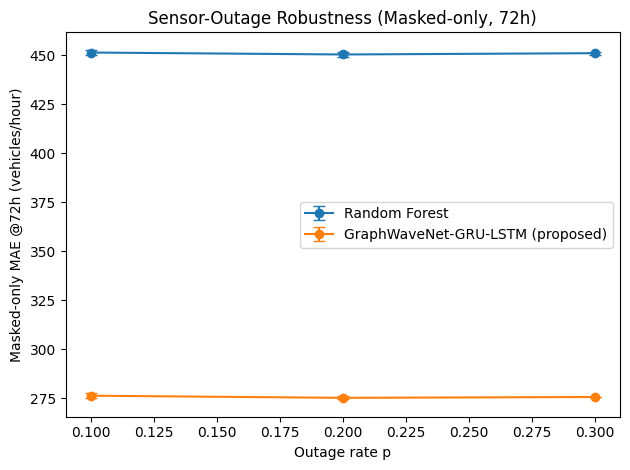

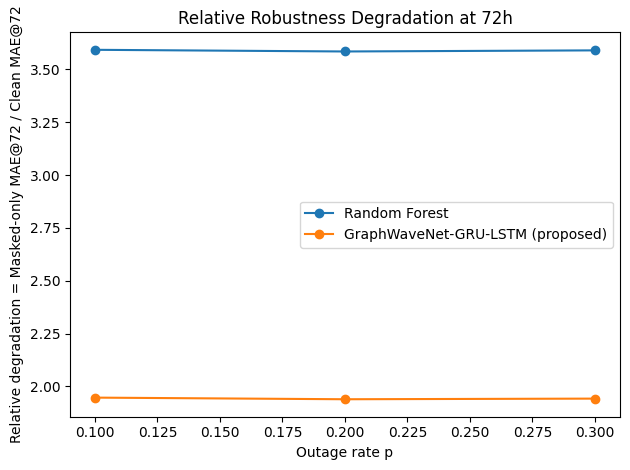

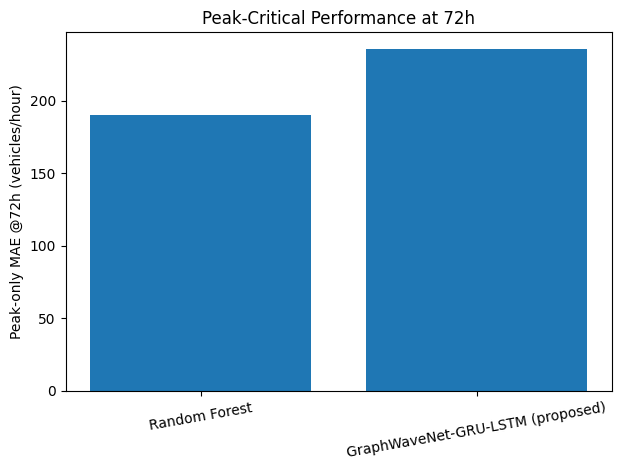

Saved Figures 1-3 to: artifacts/paper_outputs/proposed_vs_rf


In [17]:

# =========================
# 17) Plot the key robustness figures
# =========================
plt.figure()
for model_name, summary in summary_by_model.items():
    y = [summary[p]["masked"][72]["MAE_mean"] for p in OUTAGE_RATES]
    yerr = [summary[p]["masked"][72]["MAE_std"] for p in OUTAGE_RATES]
    plt.errorbar(OUTAGE_RATES, y, yerr=yerr, marker="o", capsize=4, label=model_name)
plt.xlabel("Outage rate p")
plt.ylabel("Masked-only MAE @72h (vehicles/hour)")
plt.title("Sensor-Outage Robustness (Masked-only, 72h)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure1_masked_mae72_vs_outage.png", dpi=200)
plt.show()

plt.figure()
rf_clean_72 = rf_clean_metrics[72]["MAE"]
prop_clean_72 = proposed_clean_metrics[72]["MAE"]
for model_name, summary, clean72 in [
    ("Random Forest", rf_outage_summary, rf_clean_72),
    ("GraphWaveNet-GRU-LSTM (proposed)", proposed_outage_summary, prop_clean_72),
]:
    y = [summary[p]["masked"][72]["MAE_mean"] / clean72 for p in OUTAGE_RATES]
    plt.plot(OUTAGE_RATES, y, marker="o", label=model_name)
plt.xlabel("Outage rate p")
plt.ylabel("Relative degradation = Masked-only MAE@72 / Clean MAE@72")
plt.title("Relative Robustness Degradation at 72h")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure2_relative_degradation_mae72.png", dpi=200)
plt.show()

plt.figure()
labels = ["Random Forest", "GraphWaveNet-GRU-LSTM (proposed)"]
vals = [rf_peak_metrics[72]["MAE"], proposed_peak_metrics[72]["MAE"]]
plt.bar(labels, vals)
plt.ylabel("Peak-only MAE @72h (vehicles/hour)")
plt.title("Peak-Critical Performance at 72h")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure3_peak_mae72.png", dpi=200)
plt.show()

print("Saved Figures 1-3 to:", OUTPUT_DIR)


In [18]:

# =========================
# 18) Final paper-facing summary table and notes
# =========================
summary_rows = []

summary_rows.append({
    "Section": "Clean",
    "Model": "Random Forest",
    **{f"MAE@{h}": rf_clean_metrics[h]["MAE"] for h in HORIZONS},
    **{f"RMSE@{h}": rf_clean_metrics[h]["RMSE"] for h in HORIZONS},
})
summary_rows.append({
    "Section": "Clean",
    "Model": "GraphWaveNet-GRU-LSTM (proposed)",
    **{f"MAE@{h}": proposed_clean_metrics[h]["MAE"] for h in HORIZONS},
    **{f"RMSE@{h}": proposed_clean_metrics[h]["RMSE"] for h in HORIZONS},
})
summary_rows.append({
    "Section": "Peak-only",
    "Model": "Random Forest",
    **{f"MAE@{h}": rf_peak_metrics[h]["MAE"] for h in HORIZONS},
    **{f"RMSE@{h}": rf_peak_metrics[h]["RMSE"] for h in HORIZONS},
})
summary_rows.append({
    "Section": "Peak-only",
    "Model": "GraphWaveNet-GRU-LSTM (proposed)",
    **{f"MAE@{h}": proposed_peak_metrics[h]["MAE"] for h in HORIZONS},
    **{f"RMSE@{h}": proposed_peak_metrics[h]["RMSE"] for h in HORIZONS},
})

final_summary_df = pd.DataFrame(summary_rows)
display(final_summary_df)
final_summary_df.to_csv(OUTPUT_DIR / "final_summary_table.csv", index=False)

interpretation = f"""
Core interpretation for writing:

1) Clean full-information setting:
   - Random Forest clean MAE@72 = {rf_clean_metrics[72]['MAE']:.3f}
   - Proposed clean MAE@72      = {proposed_clean_metrics[72]['MAE']:.3f}

2) Peak-only setting:
   - Random Forest peak MAE@72 = {rf_peak_metrics[72]['MAE']:.3f}
   - Proposed peak MAE@72      = {proposed_peak_metrics[72]['MAE']:.3f}

3) Outage robustness (masked-only, 72h, mean across seeds):
   - RF at p=0.30         = {rf_outage_summary[0.30]['masked'][72]['MAE_mean']:.3f} ± {rf_outage_summary[0.30]['masked'][72]['MAE_std']:.3f}
   - Proposed at p=0.30   = {proposed_outage_summary[0.30]['masked'][72]['MAE_mean']:.3f} ± {proposed_outage_summary[0.30]['masked'][72]['MAE_std']:.3f}

Recommended paper message:
- Random Forest remains the strongest baseline under full-information conditions.
- The proposed graph model is evaluated not only on average clean error, but under realistic deployment stress:
  sensor outages and peak-critical conditions.
- If the proposed model degrades less under outages, that is the central contribution.
"""
(OUTPUT_DIR / "paper_interpretation_notes.txt").write_text(interpretation)
print(interpretation)
print("Saved final summary outputs to:", OUTPUT_DIR)


,Section,Model,MAE@12,MAE@24,MAE@48,MAE@72,RMSE@12,RMSE@24,RMSE@48,RMSE@72
0,Clean,Random Forest,114.454689,115.199486,123.086647,125.602287,259.444122,263.879028,279.938904,284.719635
1,Clean,GraphWaveNet-GRU-LSTM (proposed),119.002230,125.071262,135.291464,141.881030,241.518085,253.483658,278.757509,291.515630
2,Peak-only,Random Forest,176.161179,173.930664,183.925339,190.185532,326.823669,326.485901,341.464752,348.507599
3,Peak-only,GraphWaveNet-GRU-LSTM (proposed),222.218597,226.622849,231.411102,235.210129,376.268890,379.027191,384.063660,388.636871



Core interpretation for writing:

1) Clean full-information setting:
   - Random Forest clean MAE@72 = 125.602
   - Proposed clean MAE@72      = 141.881

2) Peak-only setting:
   - Random Forest peak MAE@72 = 190.186
   - Proposed peak MAE@72      = 235.210

3) Outage robustness (masked-only, 72h, mean across seeds):
   - RF at p=0.30         = 450.962 ± 0.721
   - Proposed at p=0.30   = 275.542 ± 0.164

Recommended paper message:
- Random Forest remains the strongest baseline under full-information conditions.
- The proposed graph model is evaluated not only on average clean error, but under realistic deployment stress:
  sensor outages and peak-critical conditions.
- If the proposed model degrades less under outages, that is the central contribution.

Saved final summary outputs to: artifacts/paper_outputs/proposed_vs_rf


# End of notebook

## What you now have
This notebook produces a complete evaluation package for the paper:

- clean benchmark comparison,
- outage robustness comparison,
- peak-only comparison,
- CSV tables,
- LaTeX tables,
- figures,
- and written interpretation notes.

## Recommended writing order
1. Write the **evaluation protocol** first.  
2. Then write the **clean benchmark result** honestly.  
3. Then center the paper’s claim on **outage robustness** and **peak-critical behavior**.  
4. Use the saved figures and CSV files directly in Overleaf.

This is the correct way to tell a strong, defensible story when Random Forest is best under ideal conditions but graph structure matters under deployment stress.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

OUT_DIR = Path("paper_figures_final")
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 400,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "lines.linewidth": 2.2,
    "lines.markersize": 6,
})

def style_ax(ax, xlabel=None, ylabel=None, title=None, legend=False, ncol=1, loc="best"):
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, pad=10)
    ax.grid(True, alpha=0.25, linestyle="--")
    if legend:
        ax.legend(frameon=False, ncol=ncol, loc=loc)

def save_both(fig, stem):
    png_path = OUT_DIR / f"{stem}.png"
    pdf_path = OUT_DIR / f"{stem}.pdf"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")